In [1]:
!pip install kaggle

In [3]:
import os
os.environ['KAGGLE_TOKEN'] = 'KGAT_dd8e5dc97486ba65d62740dd940781a2'
os.environ['KAGGLE_USERNAME'] = 'nivedhika2006'

!mkdir -p ~/.kaggle
!echo '{"username":"nivedhika2006","key":"KGAT_dd8e5dc97486ba65d62740dd940781a2"}' > ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d sobhanmoosavi/us-accidents
!unzip us-accidents.zip

Dataset URL: https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents
License(s): CC-BY-NC-SA-4.0
100% 653M/653M [00:06<00:00, 108MB/s]

Archive:  us-accidents.zip
  inflating: US_Accidents_March23.csv  


Shape: (100000, 46)
['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']


/tmp/ipykernel_4544/2203931512.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Severity', data=df,


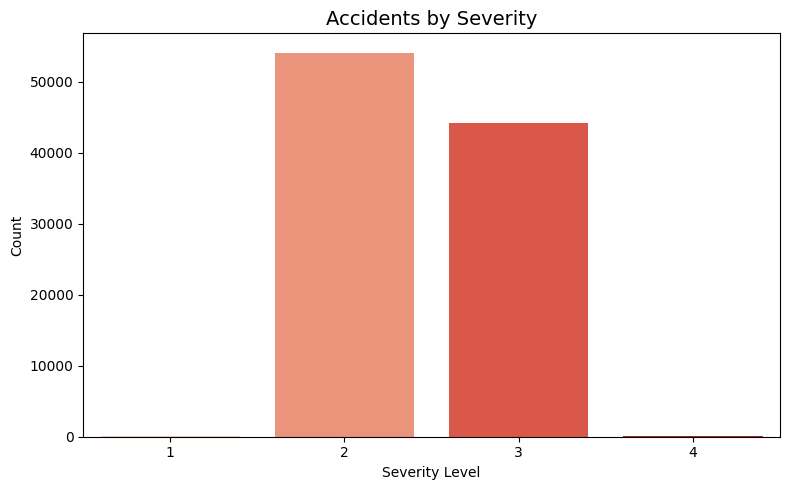

/tmp/ipykernel_4544/2203931512.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Hour', data=df, palette='Blues_d')


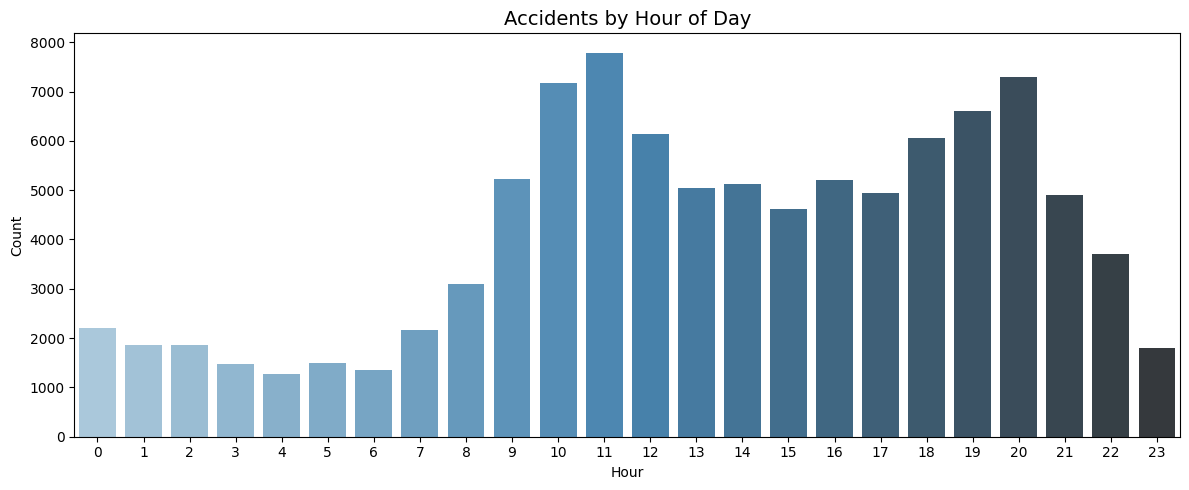

/tmp/ipykernel_4544/2203931512.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Day', data=df, order=day_order, palette='Set2')


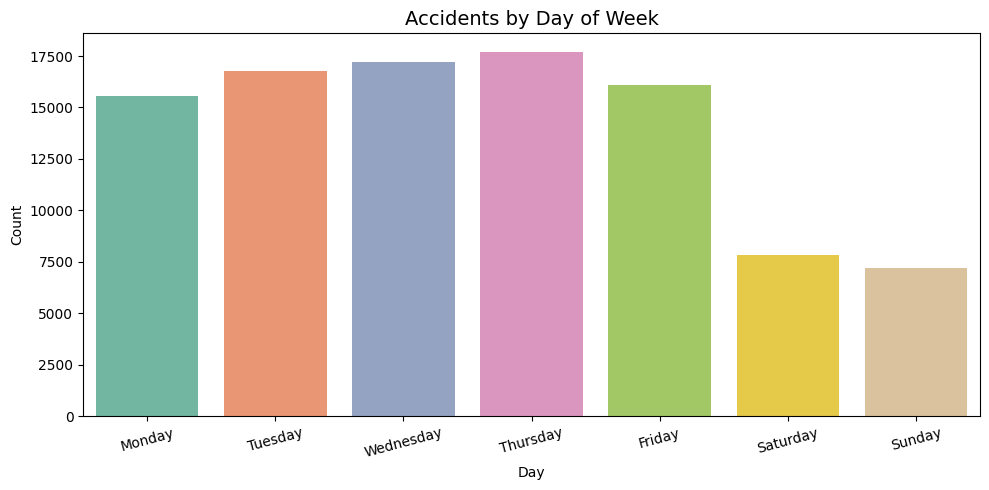

/tmp/ipykernel_4544/2203931512.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_weather.values, y=top_weather.index, palette='coolwarm')


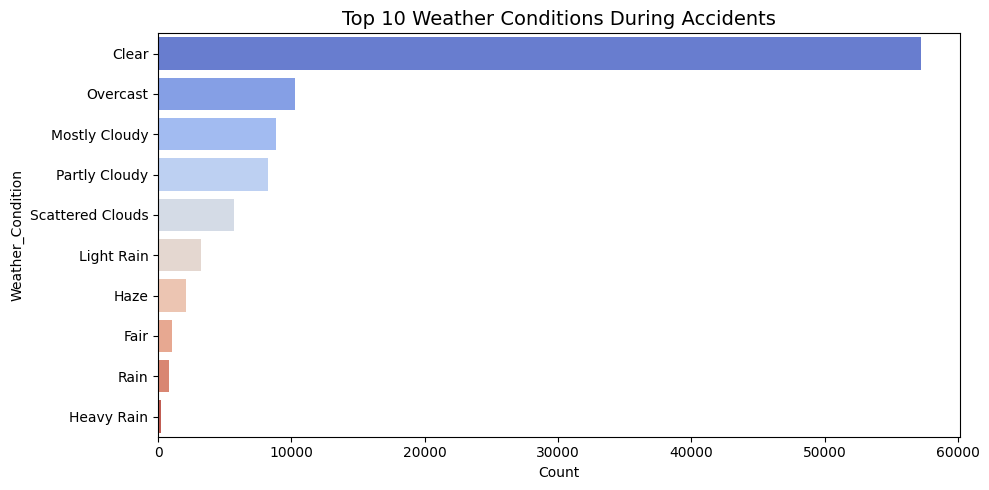

/tmp/ipykernel_4544/2203931512.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sunrise_Sunset', data=df, palette='Set1')


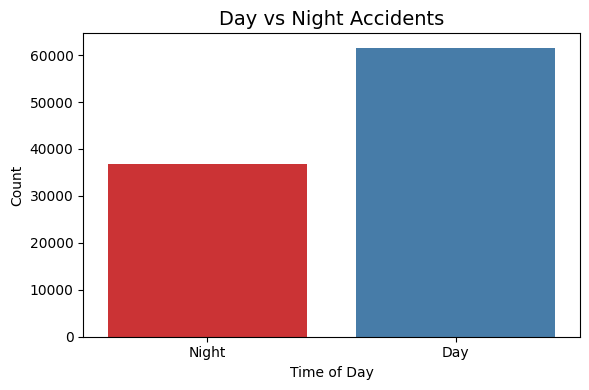

✅ All Task 05 charts saved!


In [5]:
# ============================================================
# PRODIGY INFOTECH - DATA SCIENCE INTERNSHIP
# Task 05: Traffic Accident Data Analysis
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load Dataset (using sample due to large size) ─────────
df = pd.read_csv('US_Accidents_March23.csv', nrows=100000)
print("Shape:", df.shape)
print(df.columns.tolist())

# ── Data Cleaning ─────────────────────────────────────────
df = df.dropna(subset=['Severity', 'Weather_Condition',
                        'Start_Time', 'Sunrise_Sunset'])
df['Start_Time'] = pd.to_datetime(df['Start_Time'])
df['Hour'] = df['Start_Time'].dt.hour
df['Day'] = df['Start_Time'].dt.day_name()

# ── Chart 1: Accidents by Severity ────────────────────────
plt.figure(figsize=(8, 5))
sns.countplot(x='Severity', data=df,
              palette='Reds', order=sorted(df['Severity'].unique()))
plt.title('Accidents by Severity', fontsize=14)
plt.xlabel('Severity Level')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('Task05_severity.png', dpi=150)
plt.show()

# ── Chart 2: Accidents by Hour of Day ─────────────────────
plt.figure(figsize=(12, 5))
sns.countplot(x='Hour', data=df, palette='Blues_d')
plt.title('Accidents by Hour of Day', fontsize=14)
plt.xlabel('Hour')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('Task05_by_hour.png', dpi=150)
plt.show()

# ── Chart 3: Accidents by Day of Week ─────────────────────
day_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']
plt.figure(figsize=(10, 5))
sns.countplot(x='Day', data=df, order=day_order, palette='Set2')
plt.title('Accidents by Day of Week', fontsize=14)
plt.xlabel('Day')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('Task05_by_day.png', dpi=150)
plt.show()

# ── Chart 4: Top 10 Weather Conditions ────────────────────
top_weather = df['Weather_Condition'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_weather.values, y=top_weather.index, palette='coolwarm')
plt.title('Top 10 Weather Conditions During Accidents', fontsize=14)
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('Task05_weather.png', dpi=150)
plt.show()

# ── Chart 5: Day vs Night Accidents ───────────────────────
plt.figure(figsize=(6, 4))
sns.countplot(x='Sunrise_Sunset', data=df, palette='Set1')
plt.title('Day vs Night Accidents', fontsize=14)
plt.xlabel('Time of Day')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('Task05_day_night.png', dpi=150)
plt.show()

print("✅ All Task 05 charts saved!")